## The 9-Qubit Shor Code
#### *An Implementation In Python With Qiskit*

The 9-qubit Shor Code is a simple quantum error correction code capable of correcting both X (bit-flip) and Z (phase-flip) errors, albeit at most one of each. Furthermore, the Shor Code can correct for *any* arbitary single-qubit coherent error. A single-qubit coherent error process can be expanded in terms of the Pauli operators $X$, $Z$ & $XZ$ as:

$$ U = \alpha_I I + \alpha_X X + \alpha_Z Z + \alpha_{XZ} XZ. $$

After the occurence of such an error, prior to syndrome measurement, the logical state $|\psi_L\rangle$ will be in a superposition of the states $X|\psi_L\rangle$, $Z|\psi_L\rangle$ & $XZ|\psi_L\rangle$. Measuring the error syndrome subsequently collapses this superposition into one of the four states, each of which can be individually corrected for by the Shore Code. Hence, the ability to correct each of these single Pauli errors enables the Shor Code to correct any single-qubit coherent error.


The Shor Code logical encoding of the computational basis states is as follows:

$$|0\rangle_L = \frac{(|000\rangle+|111\rangle)(|000\rangle+|111\rangle)(|000\rangle+|111\rangle)}{2\sqrt{2}}$$

$$|1\rangle_L = \frac{(|000\rangle-|111\rangle)(|000\rangle-|111\rangle)(|000\rangle-|111\rangle)}{2\sqrt{2}}$$

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from IPython.display import display
from ShorCode import SyndromeResult, CycleResult, ShorCode

## Shor Code Runthrough

1. Create instance of `ShorCode` class and set parameters for code test:

In [2]:
code = ShorCode()
error_type ='XZ'
error_qubit = 5
alpha = 1/np.sqrt(2)
beta = 1/np.sqrt(2)

2. Encode input state

In [3]:
circuit = code.prepare_logical(alpha, beta)
circuit.draw('mpl')
sv = Statevector.from_instruction(circuit)
display(sv.draw(output='latex'))

<IPython.core.display.Latex object>

3. Inject error

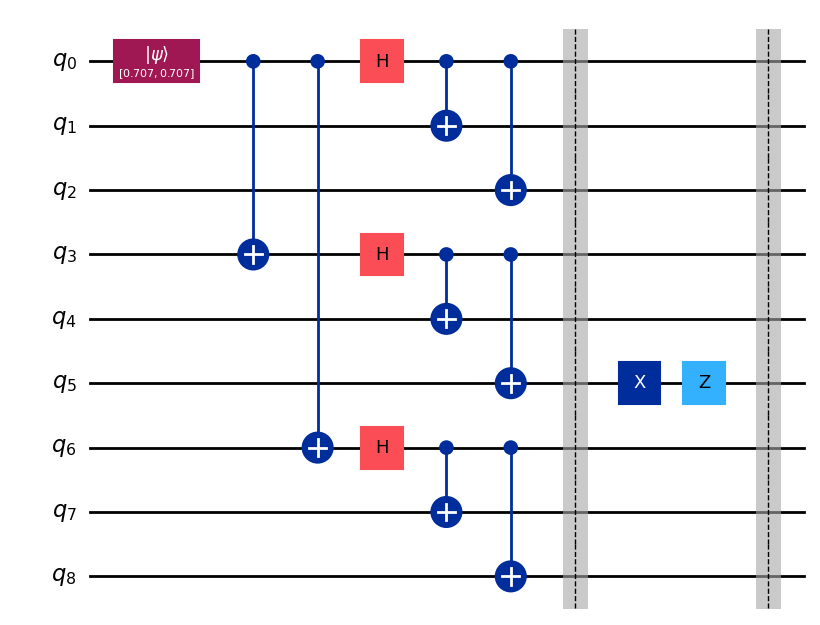

In [4]:
error_circuit = code.inject_error(circuit, error_type, error_qubit)
error_circuit.draw('mpl')

4. Measure syndrome

Illustration of the syndrome measurement ciruit is omitted here due to its large size.

In [5]:
syndrome_circuit = code.syndrome_circuit(error_circuit)
syndrome_bits, _ = code.measure_syndrome(error_circuit)
print(f"Syndrome bits: {syndrome_bits}")

Syndrome bits: [0 0 0 1 0 0 1 1]


5. Error diagnosis

In [6]:
syndrome_result = code.syndrome_decode(syndrome_bits)
print(syndrome_result)

Syndrome: 00010011
  X errors identified: [5]
  Z errors identified: [3]
  Corrections:         [('X', 5), ('Z', 3)]


6. Apply appropriate corrections

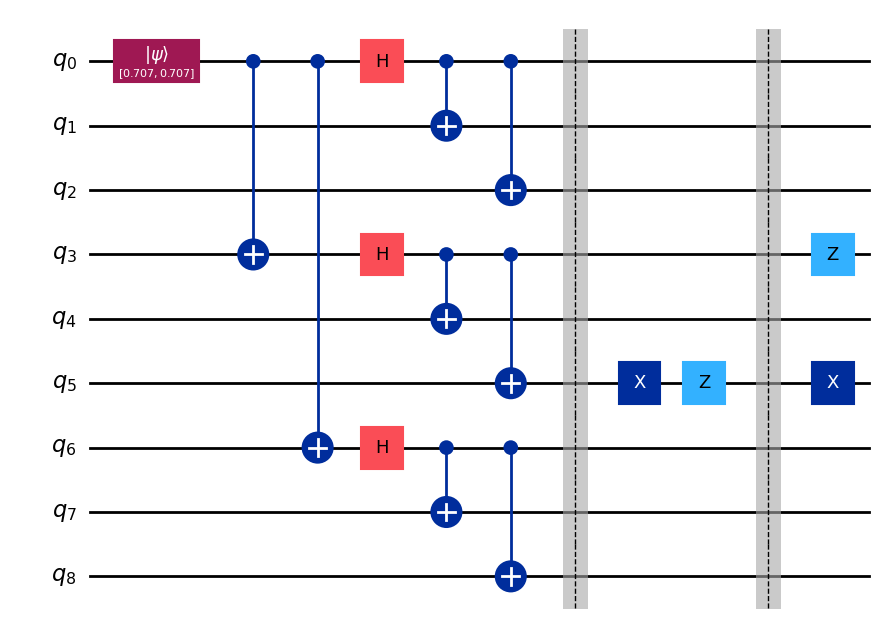

In [7]:
corrected = error_circuit.copy()
corrected.compose(code.correction_circuit(syndrome_result.corrections), inplace=True)
corrected.draw('mpl')

7. Apply reverse encoding and check qubit 0 is in original input state

Logical output state: [-0.70710678+0.j -0.70710678+0.j]


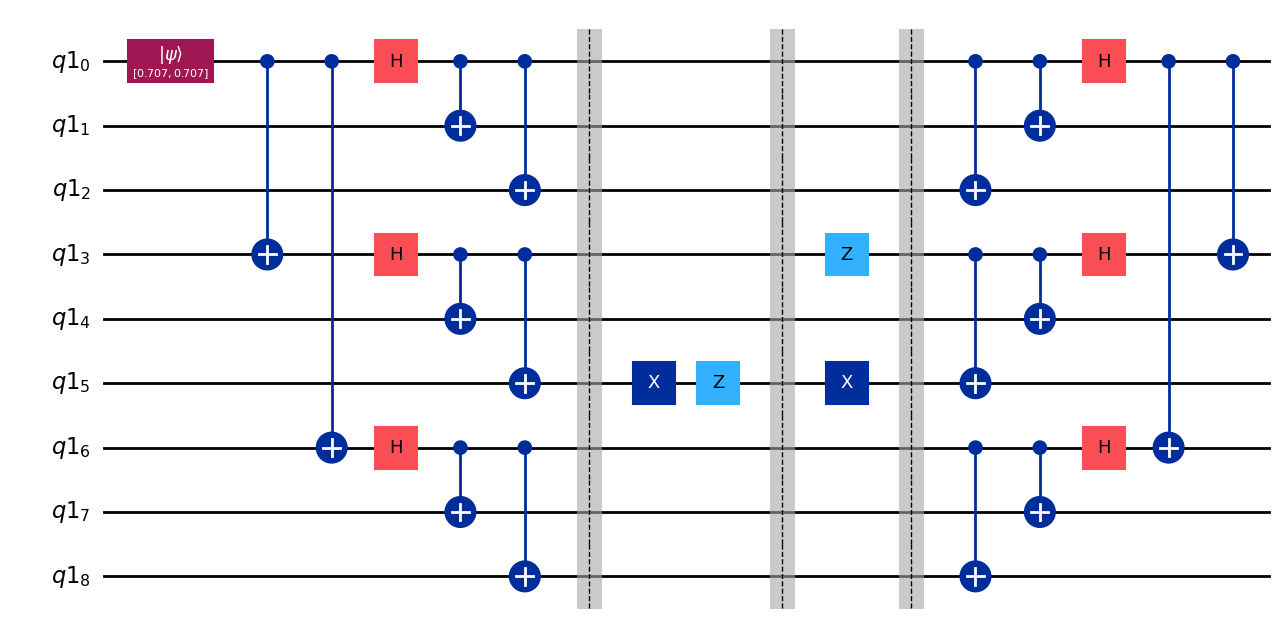

In [8]:
meas_qc = code.inverse_encode_logical(corrected)
logical_output = np.round(Statevector.from_instruction(meas_qc).data[0:2], 10)
print(f"Logical output state: {logical_output}")
meas_qc.draw('mpl')

Summaray of results

In [9]:
res = CycleResult(
            logical_input = np.array([alpha, beta]),
            error_type = error_type,
            error_qubit = error_qubit,
            syndrome = syndrome_result,
            logical_output = logical_output,
            success = all(np.isclose(logical_output, np.array([alpha, beta]))) or 
            all(np.isclose(-logical_output, np.array([alpha, beta]))), # Final logical state may pick up global phase of -1
        )
print(res)

Logical input: [0.70710678 0.70710678]
Error: XZ on qubit 5
Syndrome: 00010011
  X errors identified: [5]
  Z errors identified: [3]
  Corrections:         [('X', 5), ('Z', 3)]
Logical output: [-0.70710678+0.j -0.70710678+0.j]
Success: ✓


Note that during the error correction process, the logical state picked up a global phase of $-1$. This is however a physically identical state to the input state. 